# ECE 3715 Mini-Project 1

**Team number: 0**  
**Step 1: Sample space and axioms**

Step 1 analyzes a four-bit packet with independent bit errors. The sample space is enumerated,
event probabilities are calculated, and the exact results are compared with a simulation of 1,000,000 packets.

My team number will be **0**.

The differences are reported as as estimate minus theory and use SE to mean standard error.


In [1]:
from time import perf_counter
START = perf_counter()
from pathlib import Path
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from mp1lib import (bsc, packet_errors, attempts_until_clean, tv_distance,
                    probability_comparison)

TEAM_NUMBER = 0
SEED = TEAM_NUMBER
rng = np.random.default_rng(SEED)
rng1 = rng.spawn(1)[0]
rng2 = rng.spawn(1)[0]
rng3 = rng.spawn(1)[0]
rng4 = rng.spawn(1)[0]
rng5 = rng.spawn(1)[0]
rng6 = rng.spawn(1)[0]
rng7 = rng.spawn(1)[0]
rng8 = rng.spawn(1)[0]
rngA = rng.spawn(1)[0]
rngB = rng.spawn(1)[0]
rng_test = rng.spawn(1)[0]
print(f"Team: {TEAM_NUMBER}; seed: {SEED}")
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}, Matplotlib {matplotlib.__version__}")
FIGDIR = Path('figures')
FIGDIR.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 115, 'savefig.dpi': 160, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': .22, 'axes.spines.top': False})

def table(headers, rows):
    """Display a readable table without adding a dataframe dependency."""
    def fmt(x):
        return f'{x:.7g}' if isinstance(x, (float, np.floating)) else str(x).replace('|', r'\|')
    display(Markdown('| ' + ' | '.join(fmt(h) for h in headers) + ' |\n|' + '|'.join(['---']*len(headers)) + '|\n' +
                     '\n'.join('| ' + ' | '.join(fmt(x) for x in row) + ' |' for row in rows)))

def finish(fig, name):
    """Save a figure and display it exactly once."""
    fig.savefig(FIGDIR / f'{name}.png', bbox_inches='tight')
    plt.show()
    plt.close(fig)

CMP = ['Quantity', 'Estimate', 'Theory', 'Difference', 'SE', 'Difference/SE']

Team: 0; seed: 0
Python 3.13.5, NumPy 2.3.5, Matplotlib 3.10.8


### Library function tests
The BSC is checked at p=0 and p=1, where every bit must be preserved or flipped. 
Packet error counts are verified at these same endpoints and ensure that
q=1 gives exactly one transmission attempt. For total variation distance, identical 
PMFs give zero and disjoint point masses give one.


In [2]:
bits = np.array([[0, 1], [1, 0]], dtype=np.uint8)
assert np.array_equal(bsc(bits, 0, rng_test), bits)
assert np.array_equal(bsc(bits, 1, rng_test), 1-bits)
assert np.array_equal(packet_errors(3, 4, 0, rng_test), [0, 0, 0])
assert np.array_equal(packet_errors(3, 4, 1, rng_test), [4, 4, 4])
assert np.array_equal(attempts_until_clean(3, 1, rng_test), [1, 1, 1])
assert tv_distance([.25, .75], [.25, .75]) == 0.0
assert tv_distance([1, 0], [0, 1]) == 1.0
assert probability_comparison([0, 1], .5)[:3] == [.5, .5, 0]
print('All four library function tests passed.')


All four library function tests passed.


## Step 1 — Sample space and axioms

Error pattern is represented as $(e_1,e_2,e_3,e_4)$, where 1 means an error.

Independence gives

&emsp;&emsp;$P(e)=p^{k}(1-p)^{4-k},\qquad k=\sum_i e_i.$

The total probability is

&emsp;&emsp;$\sum_{k=0}^{4}{4\choose k}p^k(1-p)^{4-k}=(p+1-p)^4=1.$

At $p=0.1$, the individual event probabilities are

&emsp;&emsp;$P(A)=1-(0.9)^2=0.19,$

&emsp;&emsp;$P(B)={4\choose2}(0.1)^2(0.9)^2=0.0486,$

&emsp;&emsp;$P(C)=0.1.$

For $A\cap B$, five of the six two-error patterns qualify (all except 0011).

For $B\cap C$, one of the other three positions is chosen. For the triple intersection, the other error must be in position 1 or 2.

Therefore,

&emsp;&emsp;$P(A\cap B)=5(0.1)^2(0.9)^2=0.0405,$

&emsp;&emsp;$P(A\cap C)=P(A)P(C)=0.019,$

&emsp;&emsp;$P(B\cap C)=3(0.1)^2(0.9)^2=0.0243,$

&emsp;&emsp;$P(A\cap B\cap C)=2(0.1)^2(0.9)^2=0.0162.$

Inclusion-exclusion gives

&emsp;&emsp;$P(A\cup B\cup C)=0.19+0.0486+0.1-0.0405-0.019-0.0243+0.0162=0.2710.$

For a Bernoulli event of probability $\theta$,

&emsp;&emsp;$\operatorname{SE}(\hat{\theta})=\sqrt{\frac{\theta(1-\theta)}{N}}.$

At $N=10^6$, this is at most $0.0005$.

Each event's exact $\theta$ is used, including intersections and the union.


Exact sample-space mass = 0.9999999999999999


| Pattern | Exact probability | MC probability | Difference | SE |
|---|---|---|---|---|
| 0000 | 0.6561 | 0.656833 | 0.000733 | 0.0004750082 |
| 0001 | 0.0729 | 0.072507 | -0.000393 | 0.0002599723 |
| 0010 | 0.0729 | 0.072978 | 7.8e-05 | 0.0002599723 |
| 0011 | 0.0081 | 0.008221 | 0.000121 | 8.963476e-05 |
| 0100 | 0.0729 | 0.072779 | -0.000121 | 0.0002599723 |
| 0101 | 0.0081 | 0.008063 | -3.7e-05 | 8.963476e-05 |
| 0110 | 0.0081 | 0.008129 | 2.9e-05 | 8.963476e-05 |
| 0111 | 0.0009 | 0.000896 | -4e-06 | 2.99865e-05 |
| 1000 | 0.0729 | 0.072461 | -0.000439 | 0.0002599723 |
| 1001 | 0.0081 | 0.008113 | 1.3e-05 | 8.963476e-05 |
| 1010 | 0.0081 | 0.008122 | 2.2e-05 | 8.963476e-05 |
| 1011 | 0.0009 | 0.000922 | 2.2e-05 | 2.99865e-05 |
| 1100 | 0.0081 | 0.00816 | 6e-05 | 8.963476e-05 |
| 1101 | 0.0009 | 0.000868 | -3.2e-05 | 2.99865e-05 |
| 1110 | 0.0009 | 0.000846 | -5.4e-05 | 2.99865e-05 |
| 1111 | 0.0001 | 0.000102 | 2e-06 | 9.9995e-06 |

| Quantity | Estimate | Theory | Difference | SE | Difference/SE |
|---|---|---|---|---|---|
| A | 0.189461 | 0.19 | -0.000539 | 0.0003923009 | -1.373945 |
| B | 0.048808 | 0.0486 | 0.000208 | 0.0002150303 | 0.9673054 |
| C | 0.099692 | 0.1 | -0.000308 | 0.0003 | -1.026667 |
| A ∩ B | 0.040587 | 0.0405 | 8.7e-05 | 0.0001971288 | 0.4413359 |
| A ∩ C | 0.018964 | 0.019 | -3.6e-05 | 0.0001365247 | -0.2636885 |
| B ∩ C | 0.024397 | 0.0243 | 9.7e-05 | 0.0001539789 | 0.6299563 |
| A ∩ B ∩ C | 0.016176 | 0.0162 | -2.4e-05 | 0.000126244 | -0.190108 |
| A ∪ B ∪ C | 0.270189 | 0.271 | -0.000811 | 0.0004444761 | -1.82462 |

Empirical inclusion-exclusion = 0.2701890; direct union = 0.2701890
All seven event differences and union within 3 SE: True
Maximum event |difference|/SE = 1.8246
All 16 pattern differences within 3 SE: True; maximum |z|=1.8008


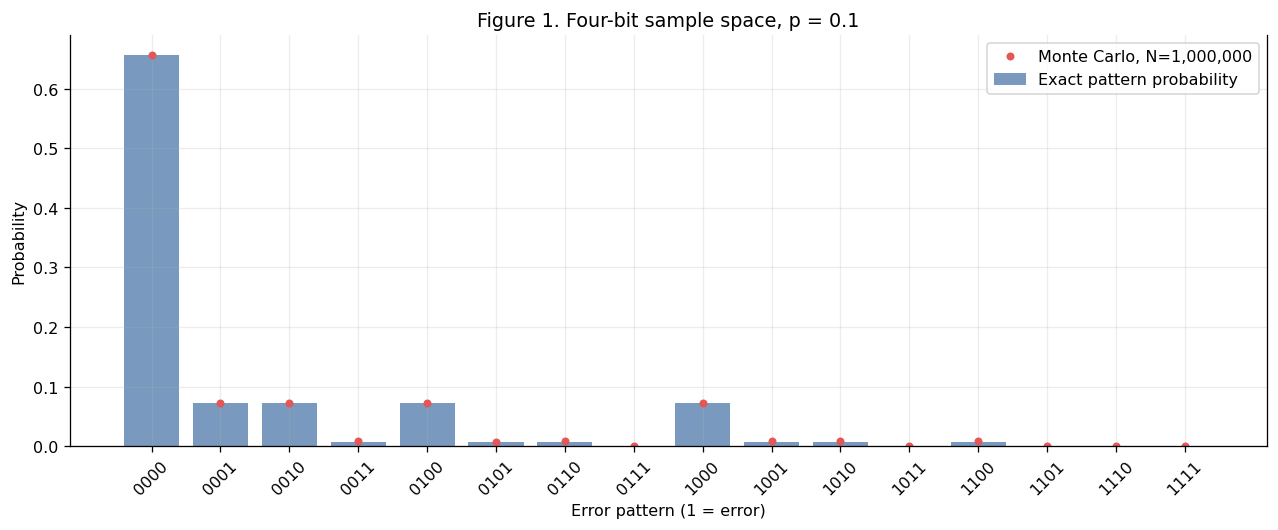

In [3]:
p1, N1 = .1, 10**6
patterns = ((np.arange(16)[:, None] >> np.arange(3, -1, -1)) & 1).astype(np.uint8)
weights = p1**patterns.sum(axis=1) * (1-p1)**(4-patterns.sum(axis=1))
errors1 = bsc(np.zeros((N1, 4), dtype=np.uint8), p1, rng1)
observed = np.bincount(errors1 @ np.array([8, 4, 2, 1]), minlength=16)/N1
labels = [''.join(map(str, row)) for row in patterns]
print(f'Exact sample-space mass = {weights.sum():.16f}')
table(['Pattern', 'Exact probability', 'MC probability', 'Difference', 'SE'],
      [[label, w, e, e-w, np.sqrt(w*(1-w)/N1)] for label,w,e in zip(labels,weights,observed)])
a, b, c = errors1[:, :2].any(axis=1), errors1.sum(axis=1)==2, errors1[:, 3].astype(bool)
pa, pb, pc = patterns[:, :2].any(axis=1), patterns.sum(axis=1)==2, patterns[:, 3].astype(bool)
names1 = ['A', 'B', 'C', 'A ∩ B', 'A ∩ C', 'B ∩ C', 'A ∩ B ∩ C', 'A ∪ B ∪ C']
masks1 = [a,b,c,a&b,a&c,b&c,a&b&c,a|b|c]
exact_masks1 = [pa,pb,pc,pa&pb,pa&pc,pb&pc,pa&pb&pc,pa|pb|pc]
rows1 = [[name]+probability_comparison(mask, weights[exact_mask].sum())
         for name,mask,exact_mask in zip(names1,masks1,exact_masks1)]
table(CMP, rows1)
emp_ie = a.mean()+b.mean()+c.mean()-(a&b).mean()-(a&c).mean()-(b&c).mean()+(a&b&c).mean()
assert np.isclose(emp_ie, (a|b|c).mean())
assert np.allclose([r[2] for r in rows1], [.19,.0486,.1,.0405,.019,.0243,.0162,.271])
print(f'Empirical inclusion-exclusion = {emp_ie:.7f}; direct union = {(a|b|c).mean():.7f}')
print(f'All seven event differences and union within 3 SE: {all(abs(r[-1]) <= 3 for r in rows1)}')
print(f'Maximum event |difference|/SE = {max(abs(r[-1]) for r in rows1):.4f}')
pattern_z = (observed-weights)/np.sqrt(weights*(1-weights)/N1)
print(f'All 16 pattern differences within 3 SE: {np.all(np.abs(pattern_z)<=3)}; maximum |z|={np.max(np.abs(pattern_z)):.4f}')
fig, ax = plt.subplots(figsize=(11,4.5), layout='constrained')
ax.bar(labels, weights, color='#4c78a8', alpha=.75, label='Exact pattern probability')
ax.plot(labels, observed, 'o', color='#e45756', markersize=4, label='Monte Carlo, N=1,000,000')
ax.set(xlabel='Error pattern (1 = error)', ylabel='Probability', title='Figure 1. Four-bit sample space, p = 0.1')
ax.tick_params(axis='x', rotation=45)
ax.legend()
finish(fig, 'figure_01')
del errors1

The no-error pattern has probability $0.9^4=0.6561$, so it dominates the sample
space. For the union, an empirical probability of $0.270189$ is obtained, compared with the
exact value $0.2710$. The difference is $-0.000811$, or about $-1.825$ standard
errors with SE $0.000444476$.

In this seed-0 run, all seven event probabilities, the union, and all 16 pattern
probabilities are within three standard errors of their exact values. These
numerical checks are used to assess whether the system agrees rather than relying solely on the plotted markers.
The union is smaller than the sum $0.3386$ because the events overlap.

## Step 2 — Conditional probability and Bayes

Let $E$ be a bit error and $F$ a flag. The prior is $P(E)=p$, and the circuit has
$P(F\mid E)=0.95$ and $P(F\mid E^c)=0.02$.

The law of total probability gives the denominator

&emsp;&emsp;$P(F)=P(F\mid E)P(E)+P(F\mid E^c)P(E^c)$

&emsp;&emsp;$=0.95p+0.02(1-p)=0.02+0.93p.$

Bayes' rule then gives

&emsp;&emsp;$P(E\mid F)=\frac{P(F\mid E)P(E)}{P(F)}$

&emsp;&emsp;$=\frac{0.95p}{0.95p+0.02(1-p)}=\frac{0.95p}{0.02+0.93p}.$

For the crossover, set $P(E\mid F)=\frac12$. Then

&emsp;&emsp;$0.95p=\frac12(0.02+0.93p)$

&emsp;&emsp;$0.485p=0.01$

&emsp;&emsp;$p^*=\frac{0.01}{0.485}=0.0206.$

At $p^*$, the flag rate is

&emsp;&emsp;$P(F)=0.02+0.93p^*=0.0392,$

so $N=10^7$ bits should give about 391,000 flags.

The empirical posterior is $\hat r=n_{FE}/n_F$, where $n_F$ is the number of flags and $n_{FE}$ is the number
of flags on bits that are truly in error. Given $n_F$, each flag is a Bernoulli($r$) trial, so

&emsp;&emsp;$\operatorname{SE}(\hat r)=\sqrt{\frac{r(1-r)}{n_F}}$

with the exact $r=0.5$.


| p | P(F) | Posterior |
|---|---|---|
| 0.1 | 0.113 | 0.840708 |
| 0.01 | 0.0293 | 0.3242321 |
| 0.001 | 0.02093 | 0.04538939 |

Crossover p* = 0.020619 (0.0206 to three significant figures)
Flags obtained = 391,255 of 10,000,000; flagged and in error = 195,406


| Quantity | Estimate | Theory | Difference | SE | Difference/SE |
|---|---|---|---|---|---|
| P(F) | 0.0391255 | 0.03917526 | -4.975773e-05 | 6.13519e-05 | -0.8110219 |
| Posterior at p* | 0.4994339 | 0.5 | -0.000566127 | 0.0007993557 | -0.7082291 |

Both differences within 3 SE: True


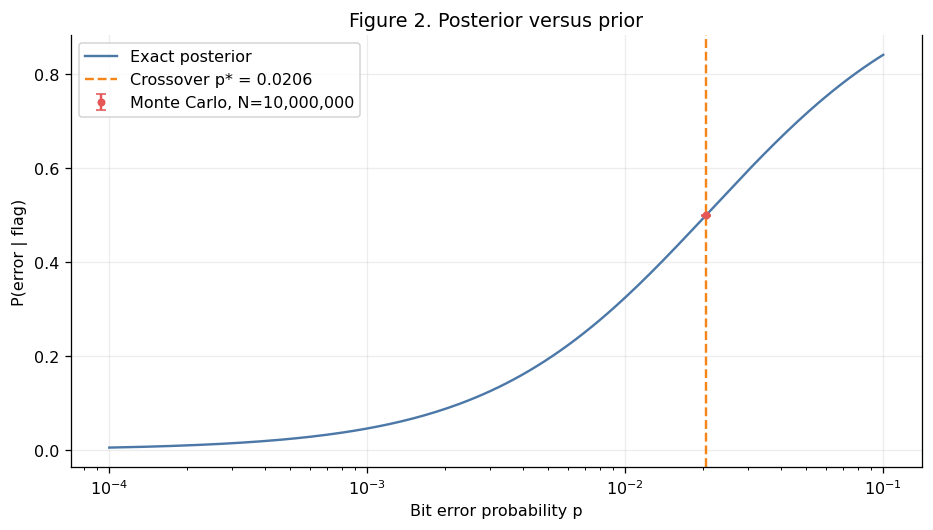

In [4]:
TPR, FPR = .95, .02
post = lambda p: TPR*np.asarray(p) / (TPR*np.asarray(p) + FPR*(1-np.asarray(p)))
p2s = [.1, .01, .001]
table(['p', 'P(F)', 'Posterior'], [[p, TPR*p+FPR*(1-p), float(post(p))] for p in p2s])
assert np.isclose(post(.001), .0454, atol=5e-4)
pstar = .5*FPR / (TPR - .5*(TPR-FPR))
assert np.isclose(post(pstar), .5) and f'{pstar:.3g}' == '0.0206'
print(f'Crossover p* = {pstar:.6f} ({pstar:.3g} to three significant figures)')

N2 = 10**7
err2 = bsc(np.zeros(N2, dtype=np.uint8), pstar, rng2).astype(bool)
flag2 = rng2.random(N2) < np.where(err2, TPR, FPR)
nf, nfe = int(flag2.sum()), int((flag2 & err2).sum())
r_hat, pf = nfe/nf, TPR*pstar + FPR*(1-pstar)
se_r, se_f = np.sqrt(.25/nf), np.sqrt(pf*(1-pf)/N2)
print(f'Flags obtained = {nf:,} of {N2:,}; flagged and in error = {nfe:,}')
table(CMP, [['P(F)', nf/N2, pf, nf/N2-pf, se_f, (nf/N2-pf)/se_f],
            ['Posterior at p*', r_hat, .5, r_hat-.5, se_r, (r_hat-.5)/se_r]])
print(f'Both differences within 3 SE: {abs(nf/N2-pf) <= 3*se_f and abs(r_hat-.5) <= 3*se_r}')
del err2, flag2

pg = np.logspace(-4, -1, 200)
fig, ax = plt.subplots(figsize=(8,4.5), layout='constrained')
ax.semilogx(pg, post(pg), color='#4c78a8', label='Exact posterior')
ax.axvline(pstar, color='#f58518', ls='--', label=f'Crossover p* = {pstar:.3g}')
ax.errorbar([pstar], [r_hat], yerr=[se_r], fmt='o', color='#e45756', markersize=4, capsize=3,
            label='Monte Carlo, N=10,000,000')
ax.set(xlabel='Bit error probability p', ylabel='P(error | flag)', title='Figure 2. Posterior versus prior')
ax.legend()
finish(fig, 'figure_02')


The posterior is $0.0454$ at $p=0.001$, $0.324$ at $p=0.01$, and $0.841$ at $p=0.1$, and it equals
$0.5$ at $p^*=0.0206$. The simulation at $p^*$ gave $391{,}255$ flags, of which $195{,}406$ were true errors.
The empirical posterior is $0.499434$ compared with $0.5$, a difference of $-0.000566$, or
about $-0.708$ standard errors with SE $0.000799$. The flag rate is $0.0391255$ compared with
$0.0391753$, a difference of $-0.0000498$, or $-0.811$ standard errors with SE $0.0000614$.

A flag from a 95 percent accurate circuit means little on a good link because real errors are rare.
At $p=0.001$, only about $1$ in $1000$ bits is in error, but $2$ percent of the other $999$ are
still flagged, so about $955$ of every $1000$ flags are false alarms. The flag only becomes
trustworthy once errors are common enough that the real ones outnumber the false alarms.


## Step 3 — Independence

### Part 1 — Pairwise Independence vs. Mutual Independence

Flip two independent fair coins and define:

- $E_1$: the first coin lands heads.
- $E_2$: the second coin lands heads.
- $E_3$: the two coins match.

The sample space is

&emsp;&emsp;$\Omega=\{HH,HT,TH,TT\},$

where every outcome has probability $1/4$.

The individual probabilities are

&emsp;&emsp;$P(E_1)=P(E_2)=P(E_3)=\frac{1}{2}.$

For $E_1$ and $E_2$,

&emsp;&emsp;$P(E_1\cap E_2)=P(HH)=\frac{1}{4},$

while

&emsp;&emsp;$P(E_1)P(E_2)=\frac{1}{2}\cdot\frac{1}{2}=\frac{1}{4}.$

For $E_1$ and $E_3$,

&emsp;&emsp;$P(E_1\cap E_3)=P(HH)=\frac{1}{4},$

while

&emsp;&emsp;$P(E_1)P(E_3)=\frac{1}{2}\cdot\frac{1}{2}=\frac{1}{4}.$

For $E_2$ and $E_3$,

&emsp;&emsp;$P(E_2\cap E_3)=P(HH)=\frac{1}{4},$

while

&emsp;&emsp;$P(E_2)P(E_3)=\frac{1}{2}\cdot\frac{1}{2}=\frac{1}{4}.$

Therefore, all three pairs satisfy

&emsp;&emsp;$P(E_i\cap E_j)=P(E_i)P(E_j),$

so $E_1$, $E_2$, and $E_3$ are pairwise independent.

To test mutual independence,

&emsp;&emsp;$P(E_1\cap E_2\cap E_3)=P(HH)=\frac{1}{4}.$

However,

&emsp;&emsp;$P(E_1)P(E_2)P(E_3)=\left(\frac{1}{2}\right)^3=\frac{1}{8}.$

Since

&emsp;&emsp;$\frac{1}{4}\neq\frac{1}{8},$

the three events are pairwise independent but not mutually independent.


In [5]:
# Step 3, Part 1: Pairwise independence versus mutual independence

N3 = 10**6

# Represent heads as 1 and tails as 0
coin1 = rng3.integers(0, 2, size=N3)
coin2 = rng3.integers(0, 2, size=N3)

# Define events
E1 = coin1 == 1
E2 = coin2 == 1
E3 = coin1 == coin2

# Individual probabilities
pE1 = np.mean(E1)
pE2 = np.mean(E2)
pE3 = np.mean(E3)

# Pairwise joint probabilities
pE1E2 = np.mean(E1 & E2)
pE1E3 = np.mean(E1 & E3)
pE2E3 = np.mean(E2 & E3)

# Triple joint probability
pE1E2E3 = np.mean(E1 & E2 & E3)

# Products of marginal probabilities
prodE1E2 = pE1 * pE2
prodE1E3 = pE1 * pE3
prodE2E3 = pE2 * pE3
prodE1E2E3 = pE1 * pE2 * pE3

print("Individual event probabilities:")
table(
    ["Event", "Estimate", "Exact"],
    [
        ["P(E1)", pE1, 0.5],
        ["P(E2)", pE2, 0.5],
        ["P(E3)", pE3, 0.5]
    ]
)

print("Pairwise and mutual independence comparisons:")
table(
    ["Comparison", "Joint Probability", "Product of Marginals", "Difference"],
    [
        ["E1 and E2", pE1E2, prodE1E2, pE1E2 - prodE1E2],
        ["E1 and E3", pE1E3, prodE1E3, pE1E3 - prodE1E3],
        ["E2 and E3", pE2E3, prodE2E3, pE2E3 - prodE2E3],
        ["E1 and E2 and E3", pE1E2E3, prodE1E2E3, pE1E2E3 - prodE1E2E3]
    ]
)

print(f"P(E1 and E2 and E3) ≈ {pE1E2E3:.6f}")
print(f"P(E1)P(E2)P(E3)   ≈ {prodE1E2E3:.6f}")


Individual event probabilities:


| Event | Estimate | Exact |
|---|---|---|
| P(E1) | 0.499663 | 0.5 |
| P(E2) | 0.50037 | 0.5 |
| P(E3) | 0.499563 | 0.5 |

Pairwise and mutual independence comparisons:


| Comparison | Joint Probability | Product of Marginals | Difference |
|---|---|---|---|
| E1 and E2 | 0.249798 | 0.2500164 | -0.0002183753 |
| E1 and E3 | 0.249798 | 0.2496131 | 0.0001848527 |
| E2 and E3 | 0.249798 | 0.2499663 | -0.0001683383 |
| E1 and E2 and E3 | 0.249798 | 0.1248989 | 0.1248991 |

P(E1 and E2 and E3) ≈ 0.249798
P(E1)P(E2)P(E3)   ≈ 0.124899


The numerical results confirm the analytical result.

For each pair of events, the estimated joint probability is approximately equal to the product of the estimated marginal probabilities. Each of these values should be close to

&emsp;&emsp;$0.25.$

This supports the conclusion that the events are pairwise independent.

For all three events together,

&emsp;&emsp;$P(E_1\cap E_2\cap E_3)\approx0.25,$

while

&emsp;&emsp;$P(E_1)P(E_2)P(E_3)\approx0.125.$

These values are clearly different, confirming that the three events are not mutually independent.

### Part 2 — Conditional Independence and a Common Cause

Let the transmitted bit be $X$, where

&emsp;&emsp;$P(X=0)=P(X=1)=\frac{1}{2}.$

Two receivers observe the transmitted bit through independent channels.

Receiver 1 has bit error probability

&emsp;&emsp;$p_1=0.1,$

and Receiver 2 has bit error probability

&emsp;&emsp;$p_2=0.3.$

Let $Y_1$ and $Y_2$ denote the outputs of the two receivers.

Although the errors introduced by the two channels are independent, both receiver outputs depend on the same transmitted bit $X$. Therefore, $X$ acts as a common cause that can make the receiver outputs dependent when the value of $X$ is not known.

The Pearson correlation coefficient is estimated for:

1. all $10^6$ transmissions,
2. the subset where $X=0$, and
3. the subset where $X=1$.

Conditioning on $X$ removes the shared source of variation, so the two conditional correlations are expected to be approximately zero.


In [6]:
# Step 3, Part 2: Dependence caused by a shared transmitted bit

N3_part2 = 10**6

# Transmitted bit: equally likely to be 0 or 1
x = rng3.integers(0, 2, size=N3_part2)

# Independent channel errors
error1 = rng3.random(N3_part2) < 0.1
error2 = rng3.random(N3_part2) < 0.3

# Receiver outputs
y1 = np.bitwise_xor(x, error1.astype(np.uint8))
y2 = np.bitwise_xor(x, error2.astype(np.uint8))

# Unconditional correlation
r_all = np.corrcoef(y1, y2)[0, 1]

# Conditional subsets
mask_x0 = x == 0
mask_x1 = x == 1

r_x0 = np.corrcoef(y1[mask_x0], y2[mask_x0])[0, 1]
r_x1 = np.corrcoef(y1[mask_x1], y2[mask_x1])[0, 1]

# Number of samples
n_all = N3_part2
n_x0 = int(np.sum(mask_x0))
n_x1 = int(np.sum(mask_x1))

# Large-sample standard error for Pearson correlation
se_all = (1 - r_all**2) / np.sqrt(n_all - 3)
se_x0 = (1 - r_x0**2) / np.sqrt(n_x0 - 3)
se_x1 = (1 - r_x1**2) / np.sqrt(n_x1 - 3)

table(
    ["Condition", "Samples", "Correlation", "SE", "|Correlation| / SE"],
    [
        ["Unconditional", n_all, r_all, se_all, abs(r_all) / se_all],
        ["Given X = 0", n_x0, r_x0, se_x0, abs(r_x0) / se_x0],
        ["Given X = 1", n_x1, r_x1, se_x1, abs(r_x1) / se_x1]
    ]
)

print("Samples with X = 0:", f"{n_x0:,}")
print("Samples with X = 1:", f"{n_x1:,}")
print(
    "Both conditional subsets contain at least 100,000 samples:",
    n_x0 >= 100_000 and n_x1 >= 100_000
)

print()
print(f"Unconditional correlation = {r_all:.6f}, SE = {se_all:.6f}")
print(f"Correlation given X = 0 = {r_x0:.6f}, SE = {se_x0:.6f}")
print(f"Correlation given X = 1 = {r_x1:.6f}, SE = {se_x1:.6f}")


| Condition | Samples | Correlation | SE | \|Correlation\| / SE |
|---|---|---|---|---|
| Unconditional | 1000000 | 0.3195721 | 0.000897875 | 355.9204 |
| Given X = 0 | 500721 | -0.0005108253 | 0.001413199 | 0.3614674 |
| Given X = 1 | 499279 | -0.001744904 | 0.001415234 | 1.232944 |

Samples with X = 0: 500,721
Samples with X = 1: 499,279
Both conditional subsets contain at least 100,000 samples: True

Unconditional correlation = 0.319572, SE = 0.000898
Correlation given X = 0 = -0.000511, SE = 0.001413
Correlation given X = 1 = -0.001745, SE = 0.001415


The unconditional receiver outputs are dependent because both $Y_1$ and $Y_2$ depend on the same transmitted bit $X$. The shared transmitted bit therefore acts as a common cause.

When the value of $X$ is fixed, that common source of variation is removed. The only remaining randomness comes from the two independent channel errors. As a result, the estimated correlations conditioned on $X=0$ and $X=1$ should both be approximately zero within sampling error.

The unconditional correlation should be noticeably different from zero, while the two conditional correlations should be small relative to their standard errors. This demonstrates that two variables can be dependent because of a shared cause even though they become independent after conditioning on that cause.

A system that fuses two sensor readings while assuming they are independent, when they actually share a common cause, can overestimate the amount of independent information available and become overconfident in the fused result.


## Step 4 — Bernoulli trials and the Binomial

Bit $i$ represents the error by a Bernoulli indicator $X_i$, with $P(X_i=1)=p$ for every bit.
Because the 1000 bit errors are independent and have the same probability, their sum $K=\sum_{i=1}^{1000}X_i$ follows a Binomial distribution.

The exact probability mass function is

&emsp;&emsp;$P(K=k)={1000\choose k}p^k(1-p)^{1000-k},\qquad k=0,1,\ldots,1000.$

By linearity of expectation,

&emsp;&emsp;$E[K]=\sum_{i=1}^{1000}E[X_i]=1000p.$

Independence makes all pairwise covariances zero, so

&emsp;&emsp;$\operatorname{Var}(K)=\sum_{i=1}^{1000}\operatorname{Var}(X_i)=1000p(1-p).$

At $p=0.005$, the value obtained is

&emsp;&emsp;$E[K]=1000(0.005)=5,$

&emsp;&emsp;$\operatorname{Var}(K)=1000(0.005)(0.995)=4.975.$

A clean packet contains no errors. All bits must be correct, giving

&emsp;&emsp;$P(K=0)=(1-p)^{1000}.$

$N=100{,}000$ packets are simulated at each required error rate using `packet_errors` and the existing `rng4` generator. Direct Binomial draws have the same distribution as summing 1000 independent bit-error indicators per packet, without allocating the full bit matrix. Theoretical PMF is evaluated with `scipy.stats.binom.pmf` to avoid factorial overflow.

### Uncertainty in the comparisons

Unbiased sample variance is reported with `ddof=1`. For the mean, the value used it

&emsp;&emsp;$\operatorname{SE}(\bar K)=\sqrt{\sigma^2/N},\qquad \sigma^2=1000p(1-p).$

For the sample variance, the Binomial fourth central moment is

&emsp;&emsp;$\mu_4=3(\sigma^2)^2+\sigma^2[1-6p(1-p)].$

Therefore,

&emsp;&emsp;$\operatorname{SE}(S^2)=\sqrt{\frac{1}{N}\left[\mu_4-\frac{N-3}{N-1}(\sigma^2)^2\right]}.$

For the clean-packet proportion the values used are, $q=(1-p)^{1000}$ and

&emsp;&emsp;$\operatorname{SE}(\hat q)=\sqrt{q(1-q)/N}.$

The values below are the differences between the simulation estimate and its theoretical value.


Step 4: sample moments at p = 0.005


| Quantity | Estimate | Theory | Difference | SE | Difference/SE |
|---|---|---|---|---|---|
| Mean | 4.99917 | 5 | -0.00083 | 0.007053368 | -0.1176743 |
| Variance | 4.984819 | 4.975 | 0.009819159 | 0.02330842 | 0.4212709 |

Step 4: probability of a clean 1000-bit packet


| p | Estimate | Theory | Difference | SE | Difference/SE |
|---|---|---|---|---|---|
| 0.005 | 0.00678 | 0.006653969 | 0.0001260314 | 0.0002570932 | 0.4902168 |
| 0.001 | 0.36785 | 0.3676954 | 0.0001545752 | 0.00152478 | 0.1013754 |
| 0.0001 | 0.90599 | 0.9048329 | 0.001157106 | 0.0009279565 | 1.24694 |

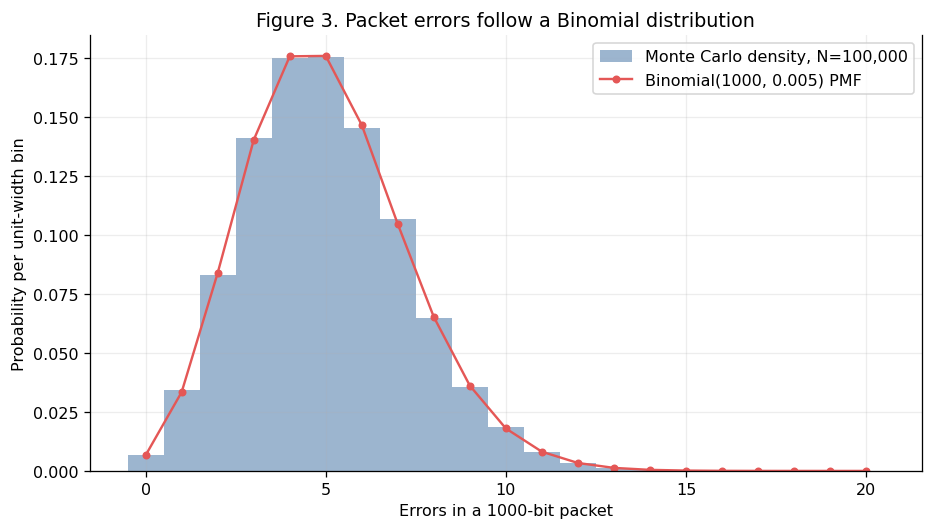

In [7]:
from scipy.stats import binom

# The existing packet_errors function and rng4 are used for this section.
N4 = 100_000
n_bits4 = 1000
p4 = 0.005
counts4 = packet_errors(N4, n_bits4, p4, rng4)

mean4 = counts4.mean()
variance4 = counts4.var(ddof=1)
theory_mean4 = n_bits4 * p4
theory_variance4 = n_bits4 * p4 * (1 - p4)
fourth_moment4 = (3 * theory_variance4**2
                  + theory_variance4 * (1 - 6 * p4 * (1 - p4)))
mean_se4 = np.sqrt(theory_variance4 / N4)
variance_se4 = np.sqrt(
    (fourth_moment4 - (N4 - 3) / (N4 - 1) * theory_variance4**2) / N4
)

print('Step 4: sample moments at p = 0.005')
table(CMP, [
    ['Mean', mean4, theory_mean4, mean4 - theory_mean4,
     mean_se4, (mean4 - theory_mean4) / mean_se4],
    ['Variance', variance4, theory_variance4, variance4 - theory_variance4,
     variance_se4, (variance4 - theory_variance4) / variance_se4]
])
assert np.isclose(theory_mean4, 5)
assert np.isclose(theory_variance4, 4.975)

clean_rows4 = []
for rate4 in [0.005, 0.001, 0.0001]:
    # The p=0.005 sample is reused and new samples are created for the other rates.
    sample4 = (counts4 if rate4 == p4
               else packet_errors(N4, n_bits4, rate4, rng4))
    q4 = float(np.exp(n_bits4 * np.log1p(-rate4)))
    clean_rows4.append([rate4] + probability_comparison(sample4 == 0, q4))

print('Step 4: probability of a clean 1000-bit packet')
table(['p', 'Estimate', 'Theory', 'Difference', 'SE', 'Difference/SE'], clean_rows4)

# Unit-width bins make histogram density comparable to the discrete PMF.
support4 = np.arange(max(int(counts4.max()), 20) + 1)
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
ax.hist(counts4, bins=np.arange(-0.5, support4[-1] + 1.5), density=True,
        color='#4c78a8', alpha=0.55, label='Monte Carlo density, N=100,000')
ax.plot(support4, binom.pmf(support4, n_bits4, p4), 'o-',
        color='#e45756', markersize=4, label='Binomial(1000, 0.005) PMF')
ax.set(xlabel='Errors in a 1000-bit packet',
       ylabel='Probability per unit-width bin',
       title='Figure 3. Packet errors follow a Binomial distribution')
ax.legend()
finish(fig, 'figure_03')


### Step 4 analysis

A sample mean of **4.99917** is obtained, compared with the theoretical mean of **5**. The difference is **−0.00083**, or **−0.118 SE**, with an SE of **0.00705337**. The unbiased sample variance is **4.984819**, compared with **4.975**; the difference is **0.009819**, or **0.421 SE**, with an SE of **0.0233084**. Both differences are smaller than one standard error, supporting the Binomial model represented in Figure 3.

At $p=0.005$, the clean-packet probability is estimated as **0.00678**, compared with **0.00665397**. The difference is **0.00012603**, or **0.490 SE**, with an SE of **0.00025709**. Although the bit error probability is only 0.5%, the exact probability that all 1000 bits survive is only about **0.6654%**; almost every packet has at least one error.

At $p=0.001$, the estimate is **0.36785**, compared with the theoretical value of **0.3676954**, giving a difference of **0.0001546** and an SE of **0.0015248** (**0.101 SE**). At $p=0.0001$, the estimate is **0.90599**, compared with **0.9048329**, giving a difference of **0.0011571** and an SE of **0.0009280** (**1.247 SE**). All three clean-packet comparisons are within three standard errors. Reducing the bit error rate substantially improves packet reliability because a packet is clean only when every bit is correct.


## Step 5 — The Poisson approximation

The total variation distance between two pmfs $P$ and $Q$ on the same support is defined as half the sum of the absolute differences:

&emsp;&emsp;$d_{TV}(P,Q)=\frac{1}{2}\sum_{k}\left|P(k)-Q(k)\right|.$

The factor $\frac12$ is used everywhere in this step. With it, identical pmfs give exactly $0$ and pmfs with disjoint support give exactly $1$. Both are tested in the next cell, along with a shifted pair that gives $0.5$, which checks the factor of two.

For $n=1000$ bits and error probability $p$, the two pmfs are

&emsp;&emsp;$P_B(k)={1000\choose k}p^k(1-p)^{1000-k},$

&emsp;&emsp;$P_\Pi(k)=e^{-\lambda}\frac{\lambda^k}{k!},\qquad\lambda=1000p.$

The Binomial has support $0,\ldots,1000$ and the Poisson has infinite support, so both are truncated to $k=0,\ldots,K$ with

&emsp;&emsp;$K=\left\lceil\lambda+20\sqrt{\lambda}+20\right\rceil,$

which is the mean plus twenty standard deviations plus twenty. The leftover Poisson tail $P(\Pi>K)$ is printed beside each distance and must be below $10^{-12}$. The truncated pmfs are not renormalized. Both pmfs are evaluated with `scipy.stats`, and no simulation is used, so `rng5` is not needed.

Le Cam's bound, in the same half-sum convention, is

&emsp;&emsp;$d_{TV}\left(\operatorname{Bin}(n,p),\operatorname{Poisson}(np)\right)\le np^2.$

Setting $np^2=0.01$ gives

&emsp;&emsp;$p_{LC}=\sqrt{\frac{0.01}{1000}}=\sqrt{10^{-5}}=0.00316.$

The largest $p$ with distance below $0.01$ is found by bisection on $[0.001,0.1]$. The interval is halved until its width is below $10^{-10}$. Bisection is only valid if the distance increases with $p$, so the distance is first checked on a grid across the bracket.


tv_distance tests passed: identical = 0, disjoint = 1, shifted pair = 0.5 (half-sum convention).
Step 5: total variation distance, n = 1000


| p | Mean np | K | TV distance | Poisson tail beyond K | Le Cam bound np^2 |
|---|---|---|---|---|---|
| 0.5 | 500 | 968 | 0.1660573 | 4.572865e-77 | 250 |
| 0.05 | 50 | 212 | 0.01244598 | 1.895351e-65 | 2.5 |
| 0.005 | 5 | 70 | 0.00122757 | 3.605448e-55 | 0.025 |
| 0.001 | 1 | 41 | 0.0002760706 | 2.680655e-52 | 0.001 |
| 0.0005 | 0.5 | 35 | 0.0001137711 | 2.405163e-53 | 0.00025 |

Largest leftover Poisson tail = 2.681e-52; all five are below 1e-12
All five distances are below the Barbour-Hall bound p(1-exp(-np)): True
Distance increases across all 162 grid points in [0.001, 0.1]: True
Bisection: p = 0.040394 (0.040 to two significant figures) after 30 halvings; distance there = 0.01000000
Le Cam: n p^2 = 0.01 at p = 0.003162 (0.0032 to two significant figures); distance there = 0.000783
Bisection answer is above the Le Cam value: True; ratio = 12.77


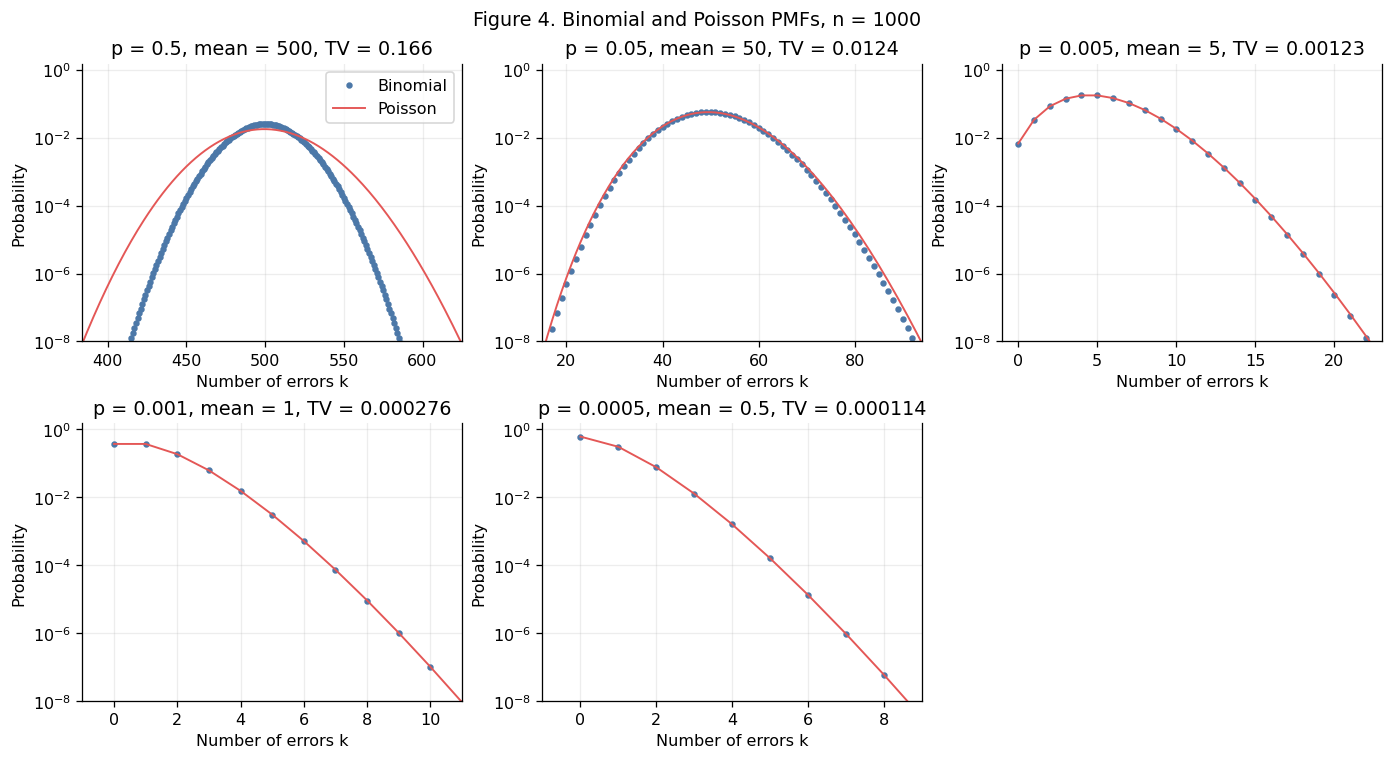

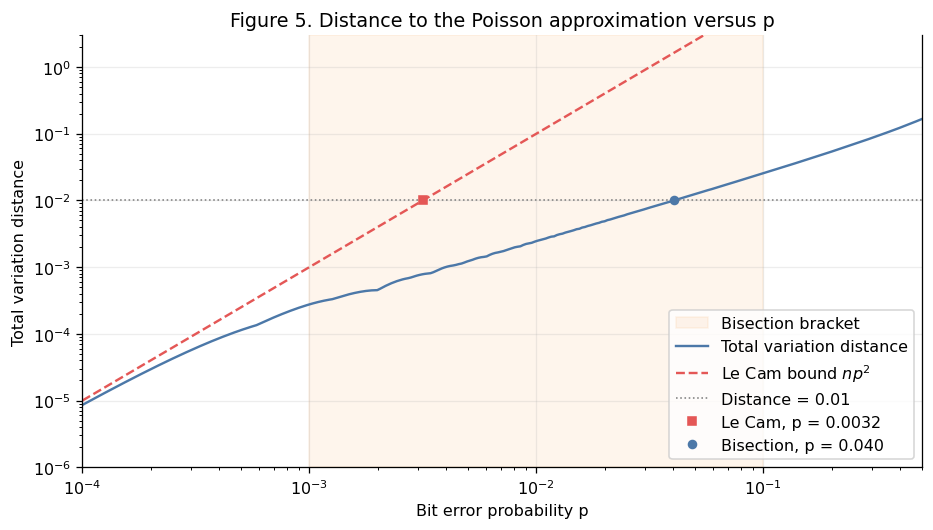

In [8]:
from scipy.stats import binom, poisson

n5 = 1000
p5s = [0.5, 0.05, 0.005, 0.001, 0.0005]

def tv5(p, n=n5):
    # Distance, truncation point K, and leftover Poisson tail for Bin(n, p) versus Poisson(np).
    lam = n * p
    K = int(np.ceil(lam + 20 * np.sqrt(lam) + 20))
    k = np.arange(K + 1)
    return tv_distance(binom.pmf(k, n, p), poisson.pmf(k, lam)), K, float(poisson.sf(K, lam))

assert tv_distance([.25, .75], [.25, .75]) == 0.0
assert tv_distance([1, 0], [0, 1]) == 1.0
assert tv_distance([.5, .5, 0], [0, .5, .5]) == 0.5
print('tv_distance tests passed: identical = 0, disjoint = 1, shifted pair = 0.5 (half-sum convention).')

rows5 = []
for p in p5s:
    d, K, tail = tv5(p)
    rows5.append([p, n5 * p, K, d, tail, n5 * p**2])
print('Step 5: total variation distance, n = 1000')
table(['p', 'Mean np', 'K', 'TV distance', 'Poisson tail beyond K', 'Le Cam bound np^2'], rows5)
assert all(r[4] < 1e-12 for r in rows5)
print(f'Largest leftover Poisson tail = {max(r[4] for r in rows5):.3e}; all five are below 1e-12')
print('All five distances are below the Barbour-Hall bound p(1-exp(-np)):',
      all(r[3] <= r[0] * (1 - np.exp(-r[1])) for r in rows5))

pgrid5 = np.logspace(-4, np.log10(0.5), 300)
dgrid5 = np.array([tv5(p)[0] for p in pgrid5])
inb5 = (pgrid5 >= 1e-3) & (pgrid5 <= 1e-1)
mono5 = bool(np.all(np.diff(dgrid5[inb5]) > 0))
print(f'Distance increases across all {inb5.sum()} grid points in [0.001, 0.1]: {mono5}')
assert mono5

target5 = 0.01
lo5, hi5 = 1e-3, 1e-1
assert tv5(lo5)[0] < target5 < tv5(hi5)[0]
iters5 = 0
while hi5 - lo5 > 1e-10:
    mid5 = (lo5 + hi5) / 2
    if tv5(mid5)[0] < target5:
        lo5 = mid5
    else:
        hi5 = mid5
    iters5 += 1
p_bis5 = (lo5 + hi5) / 2
p_lc5 = np.sqrt(target5 / n5)
print(f'Bisection: p = {p_bis5:.6f} ({p_bis5:#.2g} to two significant figures) after {iters5} halvings; '
      f'distance there = {tv5(p_bis5)[0]:.8f}')
print(f'Le Cam: n p^2 = 0.01 at p = {p_lc5:.6f} ({p_lc5:#.2g} to two significant figures); '
      f'distance there = {tv5(p_lc5)[0]:.6f}')
print(f'Bisection answer is above the Le Cam value: {p_bis5 > p_lc5}; ratio = {p_bis5 / p_lc5:.2f}')
assert np.isclose(p_lc5, 0.0032, atol=5e-5) and p_bis5 > p_lc5

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5), layout='constrained')
for ax, (p, lam, K, d, tail, _) in zip(axes.flat, rows5):
    k = np.arange(K + 1)
    pb, pp = binom.pmf(k, n5, p), poisson.pmf(k, lam)
    keep = np.flatnonzero(np.maximum(pb, pp) > 1e-8)
    ax.semilogy(k, pb, 'o', color='#4c78a8', markersize=3, label='Binomial')
    ax.semilogy(k, pp, '-', color='#e45756', linewidth=1.2, label='Poisson')
    ax.set(xlim=(keep[0] - 1, keep[-1] + 1), ylim=(1e-8, 1.5), xlabel='Number of errors k',
           ylabel='Probability', title=f'p = {p:g}, mean = {lam:g}, TV = {d:.3g}')
axes.flat[0].legend(loc='upper right')
axes.flat[5].axis('off')
fig.suptitle('Figure 4. Binomial and Poisson PMFs, n = 1000')
finish(fig, 'figure_04')

fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
ax.axvspan(1e-3, 1e-1, color='#f58518', alpha=.08, label='Bisection bracket')
ax.loglog(pgrid5, dgrid5, color='#4c78a8', label='Total variation distance')
ax.loglog(pgrid5, n5 * pgrid5**2, color='#e45756', ls='--', label='Le Cam bound $np^2$')
ax.axhline(target5, color='gray', ls=':', linewidth=1, label='Distance = 0.01')
ax.plot([p_lc5], [target5], 's', color='#e45756', markersize=5, label=f'Le Cam, p = {p_lc5:#.2g}')
ax.plot([p_bis5], [target5], 'o', color='#4c78a8', markersize=5, label=f'Bisection, p = {p_bis5:#.2g}')
ax.set(xlim=(1e-4, 0.5), ylim=(1e-6, 3), xlabel='Bit error probability p', ylabel='Total variation distance',
       title='Figure 5. Distance to the Poisson approximation versus p')
ax.legend(loc='lower right')
finish(fig, 'figure_05')


### Step 5 analysis

Figure 4 shows the Binomial and Poisson pmfs with the same mean at the five error rates. At $p=0.5$, the Poisson pmf is visibly wider than the Binomial pmf, and the distance is **0.166**. At $p=0.05$ the two still separate in the tails, with a distance of **0.0124**. At $p=0.005$, $0.001$, and $0.0005$ the curves are indistinguishable on the plot, and the distances are **0.00123**, **0.000276**, and **0.000114**. The truncation points were $K=968$, $212$, $70$, $41$, and $35$. The largest leftover Poisson tail was **2.68e-52**, far below $10^{-12}$, so the truncation did not affect any distance.

Figure 5 shows that the distance increased with $p$ at all $162$ grid points in $[0.001,0.1]$, so bisection is valid on this bracket. Bisection gave $p=0.040394$ after $30$ halvings, or **0.040** to two significant figures, with a distance of $0.01000000$ there. The Le Cam bound reaches $0.01$ at $p_{LC}=0.00316$, or **0.0032**, so the bisection answer is above it by a factor of **12.8**. This is the side it must be on, because $np^2$ is an upper limit on the distance. At $p_{LC}$ the distance is at most $0.01$ (it is actually **0.000783**), and since the distance increases with $p$, it must keep growing well past $p_{LC}$ before it reaches $0.01$. The bound is loose for larger $p$, where it is $2.5$ at $p=0.05$ and $250$ at $p=0.5$, both useless because a distance cannot exceed $1$. It gets tighter as $p$ falls, with the distance equal to **0.455** of the bound at $p=0.0005$.

The Poisson approximation is trustworthy when $p$ is small, for any $n$ large enough that $np$ is the quantity of interest. The Binomial variance is $np(1-p)$ while the Poisson variance equals the mean $np$, so the two only agree when $1-p\approx1$. At $p=0.5$ the Poisson variance of $500$ is twice the Binomial variance of $250$, which is the width gap in the first panel of Figure 4. All five distances are below the Barbour-Hall bound $p(1-e^{-np})$, so the error is at most about $p$ regardless of how large $np$ is. Le Cam's condition $np^2\ll1$, meaning $p\ll1/\sqrt{n}$, is a sufficient but more conservative version of the same requirement.


## Step 6 — Retransmissions and the Geometric Distribution

Let $T$ be the number of transmission attempts required until the first clean packet is received.

Each transmission attempt is treated as an independent Bernoulli trial with clean-packet probability $q$. Therefore, $T$ follows a geometric distribution.

This project uses the convention that the number of attempts starts at 1:

&emsp;&emsp;$T\in\{1,2,3,\ldots\}$

so $T=1$ means that the first transmission succeeds.

The geometric PMF is

&emsp;&emsp;$P(T=k)=(1-q)^{k-1}q,\qquad k=1,2,3,\ldots$

The theoretical mean is

&emsp;&emsp;$E[T]=\frac{1}{q}$

and the theoretical variance is

&emsp;&emsp;$\operatorname{Var}(T)=\frac{1-q}{q^2}.$

For this step, the clean-packet probability is fixed at

&emsp;&emsp;$q=0.7.$


In [9]:
# Step 6: simulate attempts until the first clean packet

q6 = 0.7
N6 = 10**5

attempts6 = attempts_until_clean(N6, q6, rng6)

# Sample statistics
mean6 = float(np.mean(attempts6))
var6 = float(np.var(attempts6, ddof=1))

# Theoretical statistics
mean6_theory = 1 / q6
var6_theory = (1 - q6) / q6**2

# Standard error of the sample mean
se_mean6 = np.sqrt(var6_theory / N6)

# Approximate standard error of the unbiased sample variance.
# This uses the sample fourth central moment.
centered6 = attempts6 - mean6
mu4_hat6 = np.mean(centered6**4)
se_var6 = np.sqrt(
    max(
        0.0,
        (
            mu4_hat6
            - ((N6 - 3) / (N6 - 1)) * var6**2
        ) / N6
    )
)

table(
    ["Quantity", "Estimate", "Theory", "Difference", "SE", "Difference / SE"],
    [
        [
            "Mean attempts",
            mean6,
            mean6_theory,
            mean6 - mean6_theory,
            se_mean6,
            (mean6 - mean6_theory) / se_mean6
        ],
        [
            "Variance",
            var6,
            var6_theory,
            var6 - var6_theory,
            se_var6,
            (var6 - var6_theory) / se_var6
        ]
    ]
)

print(f"Check value: theoretical mean = {mean6_theory:.4f}")
print(f"Check value: theoretical variance = {var6_theory:.4f}")


| Quantity | Estimate | Theory | Difference | SE | Difference / SE |
|---|---|---|---|---|---|
| Mean attempts | 1.42652 | 1.428571 | -0.002051429 | 0.002474358 | -0.829075 |
| Variance | 0.6121468 | 0.6122449 | -9.808689e-05 | 0.00599469 | -0.01636229 |

Check value: theoretical mean = 1.4286
Check value: theoretical variance = 0.6122


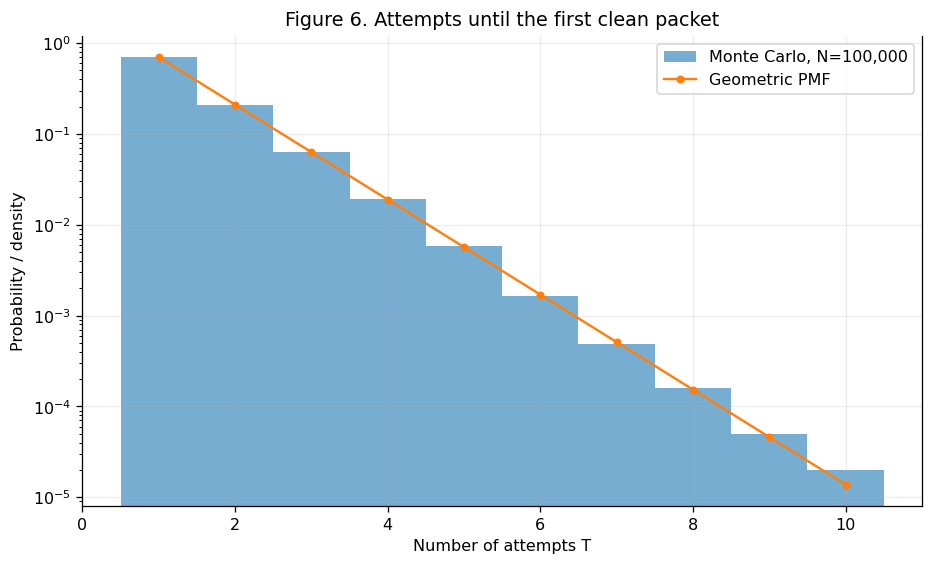

In [10]:
# Figure 6: simulated geometric distribution versus theoretical PMF

kmax6 = int(attempts6.max())
k6 = np.arange(1, kmax6 + 1)

pmf6 = q6 * (1 - q6)**(k6 - 1)

# Integer-centered histogram bins
bins6 = np.arange(0.5, kmax6 + 1.5, 1)

fig, ax = plt.subplots(figsize=(8, 4.8), layout="constrained")

ax.hist(
    attempts6,
    bins=bins6,
    density=True,
    alpha=0.6,
    label="Monte Carlo, N=100,000"
)

ax.plot(
    k6,
    pmf6,
    "o-",
    markersize=4,
    label="Geometric PMF"
)

ax.set_yscale("log")

ax.set(
    xlabel="Number of attempts T",
    ylabel="Probability / density",
    title="Figure 6. Attempts until the first clean packet"
)

ax.legend()

finish(fig, "figure_06")


### Step 6 analysis

The simulated attempt-count distribution follows the shape of the theoretical geometric PMF. The highest probability occurs at one attempt, and the probability decreases geometrically as the number of attempts increases.

For $q=0.7$, the theoretical mean is

&emsp;&emsp;$E[T]=\frac{1}{0.7}=1.4286$

and the theoretical variance is

&emsp;&emsp;$\operatorname{Var}(T)=\frac{0.3}{0.7^2}=0.6122.$

The table above reports the numerical differences between the simulated and theoretical values together with standard errors.

### Memoryless Property

The geometric distribution is memoryless, meaning

&emsp;&emsp;$P(T>m+n\mid T>m)=P(T>n).$

The required comparisons use

&emsp;&emsp;$(m,n)=(1,2),\ (3,2),\ (5,2).$


In [11]:
# Step 6: verify the memoryless property

pairs6 = [(1, 2), (3, 2), (5, 2)]
memory_rows6 = []

for m, n in pairs6:
    conditioned6 = attempts6 > m
    n_conditioned6 = int(np.sum(conditioned6))

    # Conditional estimate
    p_cond6 = float(
        np.mean(attempts6[conditioned6] > (m + n))
    )

    # Unconditional estimate
    p_uncond6 = float(
        np.mean(attempts6 > n)
    )

    # Exact geometric value
    p_theory6 = (1 - q6)**n

    # Standard errors using the exact probability
    se_cond6 = np.sqrt(
        p_theory6 * (1 - p_theory6) / n_conditioned6
    )

    se_uncond6 = np.sqrt(
        p_theory6 * (1 - p_theory6) / N6
    )

    memory_rows6.append(
        [
            f"m={m}, n={n}",
            n_conditioned6,
            p_cond6,
            p_uncond6,
            p_theory6,
            p_cond6 - p_uncond6,
            se_cond6,
            se_uncond6
        ]
    )

table(
    [
        "Pair",
        "Conditioned samples",
        "P(T>m+n | T>m)",
        "P(T>n)",
        "Theory",
        "Difference",
        "SE conditional",
        "SE unconditional"
    ],
    memory_rows6
)

print(
    f"Theoretical P(T > 2) = (1 - q)^2 = {(1-q6)**2:.6f}"
)


| Pair | Conditioned samples | P(T>m+n \| T>m) | P(T>n) | Theory | Difference | SE conditional | SE unconditional |
|---|---|---|---|---|---|---|---|
| m=1, n=2 | 29787 | 0.09134857 | 0.08992 | 0.09 | 0.001428575 | 0.001658168 | 0.0009049862 |
| m=3, n=2 | 2721 | 0.08673282 | 0.08992 | 0.09 | -0.003187181 | 0.005486276 | 0.0009049862 |
| m=5, n=2 | 236 | 0.09745763 | 0.08992 | 0.09 | 0.007537627 | 0.01862885 | 0.0009049862 |

Theoretical P(T > 2) = (1 - q)^2 = 0.090000


The conditional estimates are close to the corresponding unconditional probability, which is consistent with the memoryless property.

For $q=0.7$ and $n=2$,

&emsp;&emsp;$P(T>2)=(1-q)^2=(0.3)^2=0.09.$

A packet that has already failed five times is neither more nor less likely to succeed on the sixth attempt under this model. The reason is that every transmission attempt is assumed to be independent and to have the same clean-packet probability $q$.

On a real radio link, this independent-attempt assumption may fail if channel conditions persist over time. For example, fading or interference can make errors on successive retransmissions correlated.


## Step 7 — Expectation, Variance, and Convergence

This step compares how the running sample mean settles for two random variables:

1. the Step 4 Binomial packet-error count with $n=1000$ and $p=0.005$, and
2. the Step 6 geometric attempt count with $q=0.7$.

For the Binomial random variable $X$,

&emsp;&emsp;$E[X]=np=(1000)(0.005)=5.$

For the geometric random variable $T$,

&emsp;&emsp;$E[T]=\frac{1}{q}=\frac{1}{0.7}=1.4286.$

The running sample mean is evaluated at approximately 30 logarithmically spaced checkpoints from $N=10$ through $N=10^5$.

The entire experiment is repeated independently 200 times. Only the running means at the checkpoints are stored, so the notebook keeps approximately a $200\times30$ array rather than a $200\times100{,}000$ array of raw samples.


In [12]:
# Step 7: convergence experiment

n7 = 1000
p7 = 0.005
q7 = 0.7

runs7 = 200

checkpoints7 = np.unique(
    np.logspace(
        np.log10(10),
        np.log10(100_000),
        30
    ).astype(int)
)

binomial_means7 = np.empty(
    (runs7, len(checkpoints7))
)

geometric_means7 = np.empty(
    (runs7, len(checkpoints7))
)

# Spawn independent child generators for every repeated experiment.
children7 = rng7.spawn(2 * runs7)

for run in range(runs7):
    rng_binomial7 = children7[2 * run]
    rng_geometric7 = children7[2 * run + 1]

    binomial_sum7 = 0.0
    geometric_sum7 = 0.0
    previous7 = 0

    for j, checkpoint7 in enumerate(checkpoints7):
        block_size7 = checkpoint7 - previous7

        # Generate only the new samples required for this checkpoint.
        binomial_block7 = packet_errors(
            block_size7,
            n7,
            p7,
            rng_binomial7
        )

        geometric_block7 = attempts_until_clean(
            block_size7,
            q7,
            rng_geometric7
        )

        binomial_sum7 += np.sum(binomial_block7)
        geometric_sum7 += np.sum(geometric_block7)

        binomial_means7[run, j] = (
            binomial_sum7 / checkpoint7
        )

        geometric_means7[run, j] = (
            geometric_sum7 / checkpoint7
        )

        previous7 = checkpoint7

print(f"Number of checkpoints = {len(checkpoints7)}")
print(f"Binomial stored array shape = {binomial_means7.shape}")
print(f"Geometric stored array shape = {geometric_means7.shape}")


Number of checkpoints = 30
Binomial stored array shape = (200, 30)
Geometric stored array shape = (200, 30)


In [13]:
# Step 7: empirical spread bands and 1/sqrt(N) reference envelopes

mu_binomial7 = n7 * p7
mu_geometric7 = 1 / q7

# Mean running-mean curve across the 200 independent repetitions
center_binomial7 = np.mean(
    binomial_means7,
    axis=0
)

center_geometric7 = np.mean(
    geometric_means7,
    axis=0
)

# Central 95% empirical spread band
lower_binomial7 = np.percentile(
    binomial_means7,
    2.5,
    axis=0
)

upper_binomial7 = np.percentile(
    binomial_means7,
    97.5,
    axis=0
)

lower_geometric7 = np.percentile(
    geometric_means7,
    2.5,
    axis=0
)

upper_geometric7 = np.percentile(
    geometric_means7,
    97.5,
    axis=0
)

# Match the C/sqrt(N) reference envelope at one midpoint checkpoint.
match_index7 = len(checkpoints7) // 2

halfwidth_binomial7 = (
    upper_binomial7[match_index7]
    - lower_binomial7[match_index7]
) / 2

halfwidth_geometric7 = (
    upper_geometric7[match_index7]
    - lower_geometric7[match_index7]
) / 2

C_binomial7 = (
    halfwidth_binomial7
    * np.sqrt(checkpoints7[match_index7])
)

C_geometric7 = (
    halfwidth_geometric7
    * np.sqrt(checkpoints7[match_index7])
)

envelope_binomial7 = (
    C_binomial7 / np.sqrt(checkpoints7)
)

envelope_geometric7 = (
    C_geometric7 / np.sqrt(checkpoints7)
)


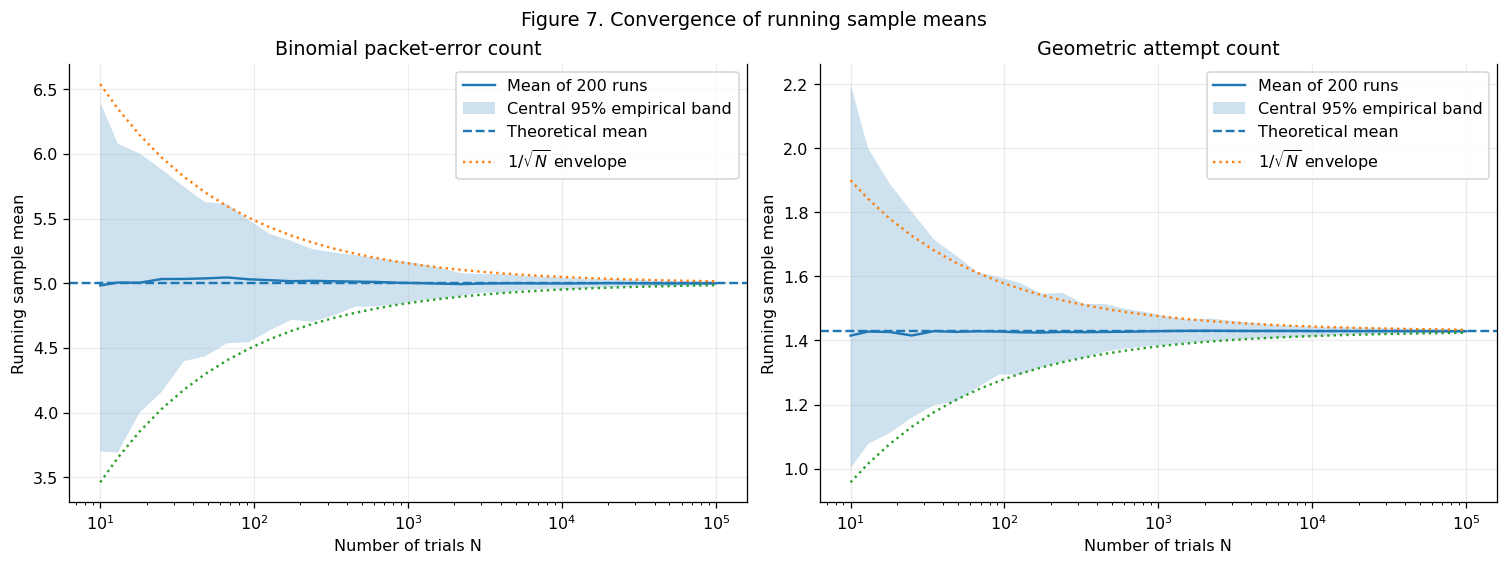

In [14]:
# Figure 7: convergence of the running sample means

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    layout="constrained"
)

# Binomial panel
ax = axes[0]

ax.plot(
    checkpoints7,
    center_binomial7,
    label="Mean of 200 runs"
)

ax.fill_between(
    checkpoints7,
    lower_binomial7,
    upper_binomial7,
    alpha=0.22,
    label="Central 95% empirical band"
)

ax.axhline(
    mu_binomial7,
    linestyle="--",
    label="Theoretical mean"
)

ax.plot(
    checkpoints7,
    mu_binomial7 + envelope_binomial7,
    linestyle=":",
    label=r"$1/\sqrt{N}$ envelope"
)

ax.plot(
    checkpoints7,
    mu_binomial7 - envelope_binomial7,
    linestyle=":"
)

ax.set_xscale("log")

ax.set(
    xlabel="Number of trials N",
    ylabel="Running sample mean",
    title="Binomial packet-error count"
)

ax.legend()


# Geometric panel
ax = axes[1]

ax.plot(
    checkpoints7,
    center_geometric7,
    label="Mean of 200 runs"
)

ax.fill_between(
    checkpoints7,
    lower_geometric7,
    upper_geometric7,
    alpha=0.22,
    label="Central 95% empirical band"
)

ax.axhline(
    mu_geometric7,
    linestyle="--",
    label="Theoretical mean"
)

ax.plot(
    checkpoints7,
    mu_geometric7 + envelope_geometric7,
    linestyle=":",
    label=r"$1/\sqrt{N}$ envelope"
)

ax.plot(
    checkpoints7,
    mu_geometric7 - envelope_geometric7,
    linestyle=":"
)

ax.set_xscale("log")

ax.set(
    xlabel="Number of trials N",
    ylabel="Running sample mean",
    title="Geometric attempt count"
)

ax.legend()

fig.suptitle(
    "Figure 7. Convergence of running sample means"
)

finish(fig, "figure_07")


In [15]:
# Step 7: determine how many Binomial trials are needed for the
# central 95% empirical band to lie within 1% of the true mean.

one_percent7 = 0.01 * mu_binomial7

target_low7 = mu_binomial7 - one_percent7
target_high7 = mu_binomial7 + one_percent7

inside_one_percent7 = (
    (lower_binomial7 >= target_low7)
    & (upper_binomial7 <= target_high7)
)

valid_indices7 = np.flatnonzero(
    inside_one_percent7
)

print(
    f"Binomial theoretical mean = {mu_binomial7:.6f}"
)

print(
    f"1% target interval = "
    f"[{target_low7:.6f}, {target_high7:.6f}]"
)

if len(valid_indices7) > 0:
    first_index7 = int(valid_indices7[0])
    trials_needed7 = int(
        checkpoints7[first_index7]
    )

    print(
        "First checkpoint whose entire central 95% empirical "
        f"band is within 1%: N = {trials_needed7:,}"
    )

    print(
        "Empirical band at that checkpoint = "
        f"[{lower_binomial7[first_index7]:.6f}, "
        f"{upper_binomial7[first_index7]:.6f}]"
    )
else:
    trials_needed7 = None

    print(
        "The complete central 95% empirical band is not "
        "within 1% by N = 100,000."
    )


Binomial theoretical mean = 5.000000
1% target interval = [4.950000, 5.050000]
First checkpoint whose entire central 95% empirical band is within 1%: N = 10,826
Empirical band at that checkpoint = [4.954166, 5.040290]


### Step 7 analysis

For both distributions, the running sample means move toward their theoretical values as the number of trials increases.

The empirical spread bands become narrower as $N$ increases. Their shape approximately follows the reference behavior

&emsp;&emsp;$\text{spread}\propto\frac{1}{\sqrt{N}},$

which is consistent with the standard error of a sample mean.

For the Binomial case, the true mean is

&emsp;&emsp;$E[X]=5.$

A 1 percent tolerance is therefore

&emsp;&emsp;$0.01(5)=0.05,$

so the target interval is

&emsp;&emsp;$4.95\leq\bar X\leq5.05.$

The code above finds the first logarithmic checkpoint for which the entire central 95% empirical band from the 200 independent repetitions lies inside this interval. The printed value of $N$ is the simulation-based answer for the current team seed.
